In [1633]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import plotly.express as px
from matplotlib.ticker import FuncFormatter


In [1634]:
dataframe = pd.read_csv('medical-charges.csv')

In [1635]:
df = dataframe.copy()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [1636]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
columns = df[['sex','smoker','region']]
encoded_columns = encoder.fit_transform(columns).toarray()
new_df = pd.DataFrame(encoded_columns,columns=encoder.get_feature_names_out(),index=df.index)
final_df = pd.concat([df.drop(labels=columns,axis=1),new_df],axis=1)
df = final_df

<Axes: >

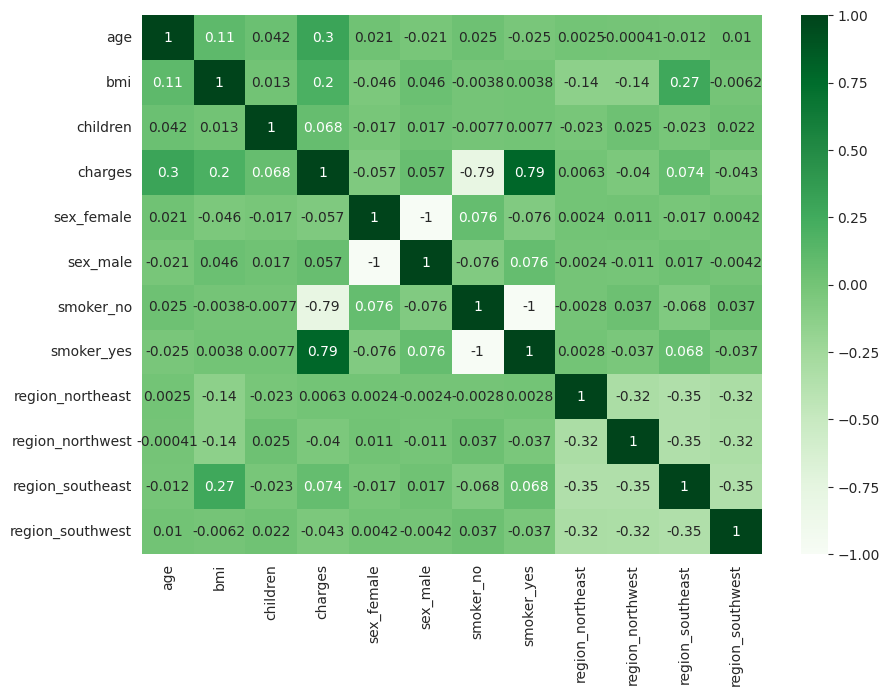

In [1637]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),cmap='Greens',annot=True)

In [1638]:
non_smoker_df = df[df['smoker_no']==1].sort_values(by='age')
smoker_df = df[df['smoker_yes']==1].sort_values(by='age')

<Axes: title={'center': 'Non-Smokers Charges Prediction: %0.3882709937544615, $4685 error margin'}, xlabel='age', ylabel='charges'>

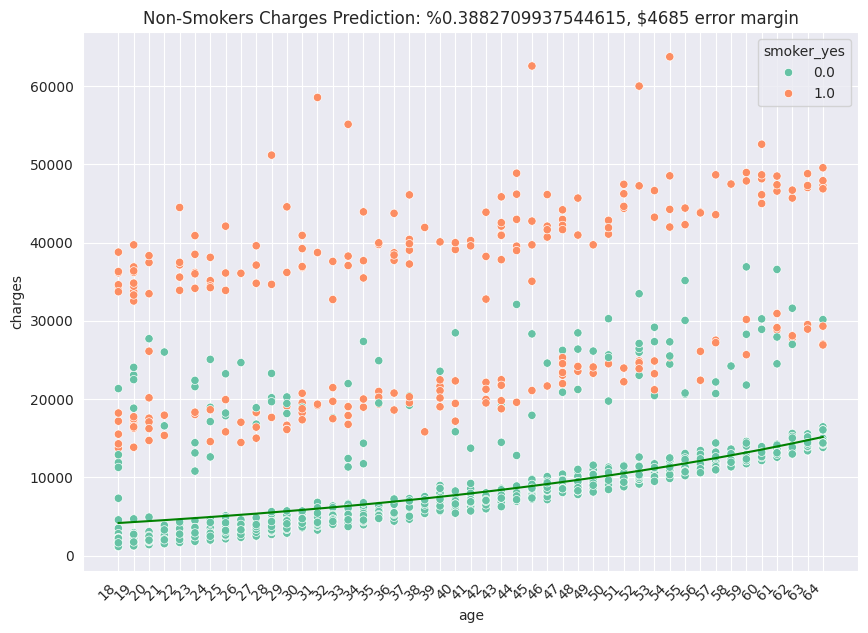

In [1731]:
from sklearn.linear_model import GammaRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error,r2_score

non_smoker_df = df[df['smoker_no']==1].sort_values(by='age')
model = GammaRegressor(alpha=0.2)
inputs = non_smoker_df[['age']]
targets = non_smoker_df['charges']
scaler = StandardScaler()
scaled_inputs = scaler.fit_transform(inputs)
model.fit(scaled_inputs,targets)
pred1 = model.predict(scaled_inputs)
rmse = root_mean_squared_error(targets,pred1)
r2_score_result = r2_score(targets,pred1)
r2_score_result, rmse

weighted_non_smoker_df = pd.DataFrame({'feature':np.append(inputs.columns,1),'weight':np.append(model.coef_,1)})
weighted_non_smoker_df.sort_values(by='weight',ascending=False)
plt.figure(figsize=(10,7))
plt.xticks(range(18,65),rotation=45,ha='right')
plt.title(f'Non-Smokers Charges Prediction: %{(r2_score_result)}, ${int(rmse)} error margin')
plt.plot(non_smoker_df['age'],pred1,'g')
sns.scatterplot(data=df,x='age',y='charges',hue='smoker_yes',palette='Set2')

<Axes: title={'center': 'Non-Smokers Charges Prediction: %0.9546792983853774, $2452 error margin'}, xlabel='age', ylabel='charges'>

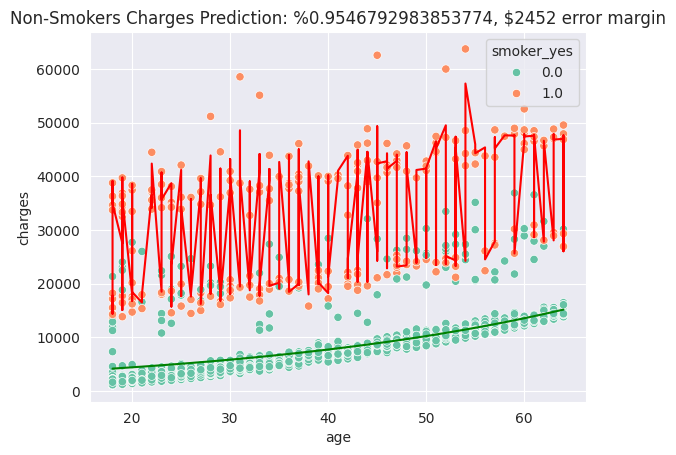

In [1672]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error,r2_score

smoker_df = df[df['smoker_yes']==1].sort_values(by='age')
# plt.figure(figsize=(10,7))
# plt.xticks(range(18,65),rotation=45,ha='right')
model = RandomForestRegressor(n_estimators=150,max_depth=5,random_state=42)
scaler = StandardScaler()
inputs = smoker_df[['age','bmi','sex_female','sex_male','smoker_no','smoker_yes','region_southeast'
                    ,'region_southwest','region_northeast','region_northwest','children']]
targets = smoker_df['charges']
scaled_inputs = scaler.fit_transform(inputs)
model.fit(scaled_inputs,targets)
pred = model.predict(scaled_inputs)
weighted_smoker_df = pd.DataFrame({'feature':np.append(scaler.feature_names_in_,1),'weight':np.append(model.feature_importances_,1)})
rmse = root_mean_squared_error(targets,pred)
r2_score_result = r2_score(targets,pred)
r2_score_result, rmse
weighted_smoker_df.sort_values(by='weight',ascending=False)
plt.title(f'Non-Smokers Charges Prediction: %{(r2_score_result)}, ${int(rmse)} error margin')
plt.plot(smoker_df['age'],pred,'r')
plt.plot(non_smoker_df['age'],pred1,'g')
sns.scatterplot(data=df,x='age',y=df['charges'],hue='smoker_yes',palette='Set2')
